# Description
## Selection of generated molecules:

* By inhibitory activity value `pIC50` > 6  

* By drug-likeness score `QED` > 0.5  

* Based on empirical rules:  
    * Synthetic accessibility score 2 < `SA` < 6  
    * Positive prediction of blood–brain barrier (BBB) permeability (not crucial for EGFR)
    * Absence of undesirable and toxic fragments  
    * Compliance with "good drug" rules  

* Based on visual evaluation of structural formulas  

* By characteristics predicted with SwissADME:  
    * BBB permeability (not crucial for EGFR)
    * No violations of Lipinski’s rules  
    * No potential toxic fragments  
 


In [181]:
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, Draw, Descriptors, SDWriter
from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams
from rdkit.Chem.rdMolDescriptors import CalcNumHBD, CalcNumHBA, CalcTPSA

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [182]:
df_train = pd.read_csv('train_dataset.csv')
df_train.drop(columns=['Unnamed: 0'], inplace=True)
df_train

,SMILES,pIC50,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,FpDensityMorgan1,FpDensityMorgan2,...,fr_priamide,fr_pyridine,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_thiazole,fr_thiophene,fr_unbrch_alkane,fr_urea
0,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,7.387216,13.399867,0.006339,-0.509118,0.583357,14.370370,383.814,1.222222,2.037037,...,0,0,0,0,0,0,0,0,0,0
1,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,6.769551,13.542332,0.041534,-0.539617,0.489619,16.500000,482.903,1.264706,2.058824,...,0,0,0,0,0,0,0,0,0,0
2,CN(c1ccccc1)c1ncnc2ccc(N/N=N/Cc3ccccn3)cc12,5.031517,4.485145,0.423142,0.423142,0.391062,11.035714,369.432,0.928571,1.785714,...,0,1,0,0,0,0,0,0,0,0
3,CC(=C(C#N)C#N)c1ccc(NC(=O)CCC(=O)O)cc1,3.301030,11.466694,0.035411,-1.026115,0.804599,9.095238,283.287,1.142857,1.714286,...,0,0,0,0,0,0,0,0,0,0
4,O=C(O)/C=C/c1ccc(O)cc1,2.522879,10.103372,0.168958,-0.983264,0.650834,10.333333,164.160,1.250000,1.833333,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25473,CN1C=C(C=N1)NC2=NC3=C(C(=CN3)C(=O)C4=CC=C(C=C4...,11.522879,13.381430,0.076930,-0.419312,0.278126,15.371429,474.500,1.257143,2.057143,...,0,0,0,0,0,0,0,0,0,0
25474,CN1CCN(CC1)C2=CC=C(C=C2)NC3=NC4=C(C(=CN4)C(=O)...,10.616185,13.526025,0.059727,-3.265343,0.257734,17.325581,606.728,0.953488,1.627907,...,0,0,0,1,0,0,0,0,0,0
25475,CN1CCN(CC1)C2=CC=C(C=C2)NC3=NC4=C(C(=CN4)C(=O)...,11.453457,13.512678,0.077413,-0.413605,0.216100,17.428571,568.657,1.023810,1.761905,...,0,0,0,0,0,0,0,0,0,0
25476,CN1CCC(CC1)N2C=C(C=N2)NC3=NC4=C(C(=CN4)C(=O)C5...,11.609065,13.491479,0.157043,-0.393973,0.238348,20.575000,546.651,1.100000,1.850000,...,0,0,0,0,0,0,0,0,0,0


In [183]:
# Generated sample of molecules

df_pred = pd.read_csv('pred_dataset_m2m_1.csv')
df_pred.drop(columns=['Unnamed: 0'], inplace=True)
df_pred

,SMILES,pIC50
0,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,7.547778
1,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,8.549603
2,CN(c1ccccc1)c1ncnc2ccc(N/N=N/Cc3ccccn3)cc12,7.926193
3,CC(=C(C#N)C#N)c1ccc(NC(=O)CCC(=O)O)cc1,3.978556
4,O=C(O)/C=C/c1ccc(O)cc1,5.286704
...,...,...
25473,CN1C=C(C=N1)NC2=NC3=C(C(=CN3)C(=O)C4=CC=C(C=C4...,9.522723
25474,CN1CCN(CC1)C2=CC=C(C=C2)NC3=NC4=C(C(=CN4)C(=O)...,9.615168
25475,CN1CCN(CC1)C2=CC=C(C=C2)NC3=NC4=C(C(=CN4)C(=O)...,9.312566
25476,CN1CCC(CC1)N2C=C(C=N2)NC3=NC4=C(C(=CN4)C(=O)C5...,10.078806


## Description of datasets

`pIC50` — logarithm of the half-maximal inhibitory concentration:  

* For `df_train` — experimental values obtained from open sources  
* For `df_pred` — values predicted by the model  

`canonical_smiles` / `SMILES` — molecular SMILES strings  



In [184]:
# SMILES molecule validation check

def is_valid_smiles(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        return mol is not None
    except:
        return False

In [185]:
valid_smiles = [smi for smi in df_pred.SMILES if is_valid_smiles(smi)]
len(valid_smiles)

[01:03:59] Conflicting single bond directions around double bond at index 13.
[01:03:59]   BondStereo set to STEREONONE and single bond directions set to NONE.
[01:03:59] Conflicting single bond directions around double bond at index 13.
[01:03:59]   BondStereo set to STEREONONE and single bond directions set to NONE.


25478

All generated compounds are SMILES-valid

# Distribution of `pIC50` in two samples

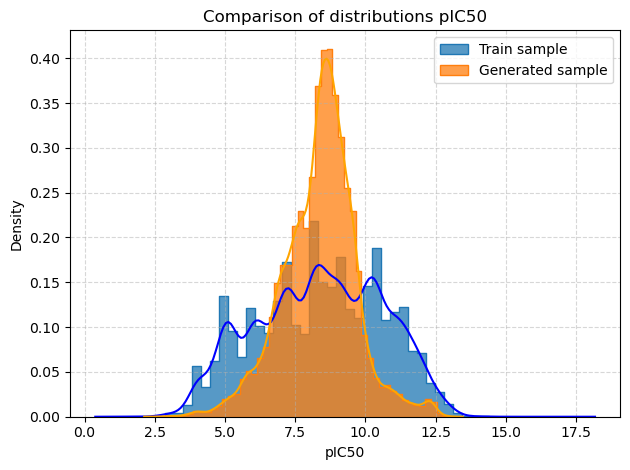

In [186]:
sns.histplot(x='pIC50', data=df_train, label='Train sample', bins=50, stat="density", element="step")
sns.kdeplot(x='pIC50', data=df_train, color="blue")

sns.histplot(x='pIC50', data=df_pred, label='Generated sample', bins=50, stat="density", element="step")
sns.kdeplot(x='pIC50', data=df_pred, color="orange")

plt.title('Сomparison of distributions pIC50')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [187]:
df_train.pIC50.describe()

count    25478.000000
mean         8.365442
std          2.233942
min          1.259637
25%          6.698970
50%          8.420216
75%         10.193820
max         17.299989
Name: pIC50, dtype: float64

In [188]:
df_pred.pIC50.describe()

count    25478.000000
mean         8.370081
std          1.309682
min          2.636655
25%          7.589350
50%          8.484611
75%          9.146809
max         12.951359
Name: pIC50, dtype: float64

The pIC50 of molecules from the generated sample has a distribution close to normal

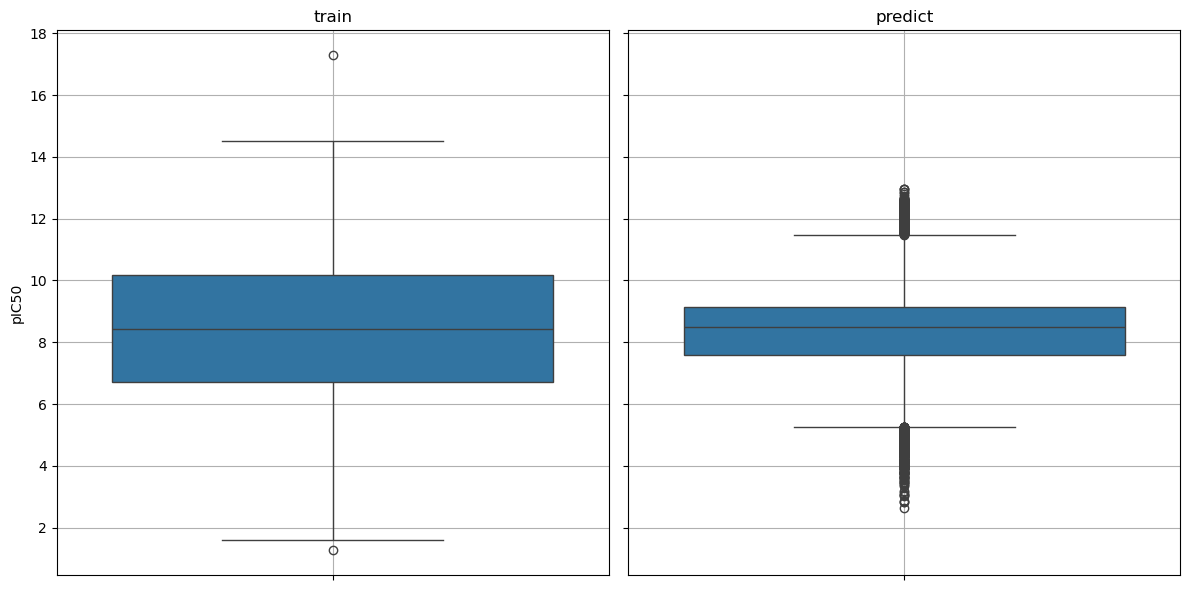

In [189]:
# To assess the differences in distributions, we will also analyze the boxplot for two samples.

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

sns.boxplot(y=df_train['pIC50'], ax=axes[0])
axes[0].set_title('train')
axes[0].grid(True)

sns.boxplot(y=df_pred['pIC50'], ax=axes[1])
axes[1].set_title('predict')
axes[1].grid(True)

plt.tight_layout()
plt.show()

Both samples have outliers

* Experimental values of `pIC50` from training data are expected to have abnormally high and abnormally low values

* For the predicted sample, this means that the model does not simply “average the values,” but can predict both very active molecules and inactive ones

The training data has a greater range than the predicted activity values. This suggests that the model favors median values

* Perhaps the model does not extrapolate well beyond the range on which it was trained

* This may also be due to limitations of the **REINVENT4** generative model. It may not generate molecules with extreme `pIC50` values.


* The generative model itself may be biased toward creating less active molecules than most compounds in the training sample.

# Molecule selection

`df_pred6` - molecules from the generated sample with `pIC50 > 6`

In [192]:
df_pred6 = pd.read_csv('pred6_dataset_m2m_1.csv')
df_pred6

,Unnamed: 0,SMILES,pIC50
0,22678,CC1(CC1)N2C=C(NN2)[C@H](C3=CC=CC4=C3C=CN=C4OC)...,9.999641
1,12334,CC(C)(C)CNc1c(C#N)cnc2c(Cl)cc(N[C@H](C3=CN(C4(...,9.998223
2,23039,CCCC1=C2C(=C(N(C2=CC(=N1)N3C4=CC(=NC(=C4C=N3)C...,9.997656
3,12652,CC(C)(C)CNc1c(C#N)cnc2c(C#N)cc(N[C@H](C3=CN(C4...,9.997578
4,22906,COC1=C(C=CC(=C1)F)C2=NC=CC(=C2)C(=O)NC3=NC4=CC...,9.996837
...,...,...,...
25382,3865,CCc1cc2c(cc1N1CCN(C3COC3)CC1)C(C)(C)c1[nH]c3cc...,6.047323
25383,4863,COc1cc2nc(Cl)nc(Nc3ccc(S(=O)(=O)O)cc3)c2cc1OC,6.038545
25384,6011,CN(C)c1ccc(C2CC(c3ccc4c(c3)OCCO4)=NN2c2ccccc2)cc1,6.036867
25385,993,N#CCCc1c(SSc2[nH]c3ccccc3c2CCC#N)[nH]c2ccccc12,6.033081


## `df_pred6` - molecules from the generated sample with `pIC50 > 6`

In [193]:
# Function for predicting passability through the GEB based on empirical rules

def predict_bbb(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    tpsa = CalcTPSA(mol)
    hbd = CalcNumHBD(mol)
    hba = CalcNumHBA(mol)

    return (mw < 500) and (1 < logp and logp < 3) and (tpsa < 90) and (hbd <= 5) and (hba <= 10)

In [194]:
# Function for calculating synthesizability assessment

def calculate_sa_score(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    try:
        complexity = (Descriptors.MolWt(mol)/100 +
                     Descriptors.NumRotatableBonds(mol)/5 +
                     len(mol.GetSubstructMatches(Chem.MolFromSmarts('[!$(*#*)&!D1]-!@[!$(*#*)&!D1]'))/10))
        rings = Descriptors.RingCount(mol)
        return max(1.0, min(6.0, 1.0 + complexity + rings*0.5))
    except:
        return 4.0

In [195]:
# Checking for toxic fragments

def contains_toxicophore(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    try:
        params = FilterCatalogParams()
        params.AddCatalog(FilterCatalogParams.FilterCatalogs.BRENK)
        params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS_A)
        return FilterCatalog(params).HasMatch(mol)
    except:
        return True

In [ ]:
# Checking the rules for “good” medicine (Lipinski's “rule of five”)

def lipinski_violations(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    violations = 0
    if Descriptors.MolWt(mol) > 500:
        violations += 1
    if Descriptors.MolLogP(mol) > 5:
        violations += 1
    if CalcNumHBD(mol) > 5:
        violations += 1
    if CalcNumHBA(mol) > 10:
        violations += 1
    return violations

In [196]:
df_filter = pd.read_csv('pred6_dataset_m2m_1.csv')
df_filter

,Unnamed: 0,SMILES,pIC50
0,22678,CC1(CC1)N2C=C(NN2)[C@H](C3=CC=CC4=C3C=CN=C4OC)...,9.999641
1,12334,CC(C)(C)CNc1c(C#N)cnc2c(Cl)cc(N[C@H](C3=CN(C4(...,9.998223
2,23039,CCCC1=C2C(=C(N(C2=CC(=N1)N3C4=CC(=NC(=C4C=N3)C...,9.997656
3,12652,CC(C)(C)CNc1c(C#N)cnc2c(C#N)cc(N[C@H](C3=CN(C4...,9.997578
4,22906,COC1=C(C=CC(=C1)F)C2=NC=CC(=C2)C(=O)NC3=NC4=CC...,9.996837
...,...,...,...
25382,3865,CCc1cc2c(cc1N1CCN(C3COC3)CC1)C(C)(C)c1[nH]c3cc...,6.047323
25383,4863,COc1cc2nc(Cl)nc(Nc3ccc(S(=O)(=O)O)cc3)c2cc1OC,6.038545
25384,6011,CN(C)c1ccc(C2CC(c3ccc4c(c3)OCCO4)=NN2c2ccccc2)cc1,6.036867
25385,993,N#CCCc1c(SSc2[nH]c3ccccc3c2CCC#N)[nH]c2ccccc12,6.033081


In [197]:
df_filter['SA_Score'] = df_filter['SMILES'].apply(calculate_sa_score)           # Assessment of synthesizability
#df_filter['BBB'] = df_filter[''].apply(predict_bbb)                       # Prediction of passage through BBB (not necessary in the case of EGFR)
df_filter['No_Toxicophore'] = ~df_filter['SMILES'].apply(contains_toxicophore)  # Content of toxic fragments
df_filter['Lipinski'] = df_filter['SMILES'].apply(lipinski_violations)          # Calculation of how many Lipinski rules have not been followed
df_filter

[01:04:52] Conflicting single bond directions around double bond at index 13.
[01:04:52]   BondStereo set to STEREONONE and single bond directions set to NONE.
[01:04:52] Conflicting single bond directions around double bond at index 13.
[01:04:52]   BondStereo set to STEREONONE and single bond directions set to NONE.
[01:05:18] Conflicting single bond directions around double bond at index 13.
[01:05:18]   BondStereo set to STEREONONE and single bond directions set to NONE.
[01:05:18] Conflicting single bond directions around double bond at index 13.
[01:05:18]   BondStereo set to STEREONONE and single bond directions set to NONE.
[01:05:44] Conflicting single bond directions around double bond at index 13.
[01:05:44]   BondStereo set to STEREONONE and single bond directions set to NONE.
[01:05:44] Conflicting single bond directions around double bond at index 13.
[01:05:44]   BondStereo set to STEREONONE and single bond directions set to NONE.


,Unnamed: 0,SMILES,pIC50,SA_Score,No_Toxicophore,Lipinski
0,22678,CC1(CC1)N2C=C(NN2)[C@H](C3=CC=CC4=C3C=CN=C4OC)...,9.999641,4.0,True,2
1,12334,CC(C)(C)CNc1c(C#N)cnc2c(Cl)cc(N[C@H](C3=CN(C4(...,9.998223,4.0,True,2
2,23039,CCCC1=C2C(=C(N(C2=CC(=N1)N3C4=CC(=NC(=C4C=N3)C...,9.997656,4.0,True,1
3,12652,CC(C)(C)CNc1c(C#N)cnc2c(C#N)cc(N[C@H](C3=CN(C4...,9.997578,4.0,True,2
4,22906,COC1=C(C=CC(=C1)F)C2=NC=CC(=C2)C(=O)NC3=NC4=CC...,9.996837,4.0,True,1
...,...,...,...,...,...,...
25382,3865,CCc1cc2c(cc1N1CCN(C3COC3)CC1)C(C)(C)c1[nH]c3cc...,6.047323,4.0,True,1
25383,4863,COc1cc2nc(Cl)nc(Nc3ccc(S(=O)(=O)O)cc3)c2cc1OC,6.038545,4.0,False,1
25384,6011,CN(C)c1ccc(C2CC(c3ccc4c(c3)OCCO4)=NN2c2ccccc2)cc1,6.036867,4.0,False,1
25385,993,N#CCCc1c(SSc2[nH]c3ccccc3c2CCC#N)[nH]c2ccccc12,6.033081,4.0,False,2


`hits` - hit molecules selected based on empirical rules

In [198]:
# Selection of molecules based on empirical rules

hits = df_filter[
    (df_filter.pIC50 > 6) & \
   # (df_filter.qed > 0.7) & \
    ((2 < df_filter.SA_Score) & (df_filter.SA_Score < 6)) & \
    #(df_filter.BBB == 1) & \
    (df_filter.No_Toxicophore == 1) & \
    (df_filter.Lipinski <= 1)].reset_index(drop=True)
hits

,Unnamed: 0,SMILES,pIC50,SA_Score,No_Toxicophore,Lipinski
0,23039,CCCC1=C2C(=C(N(C2=CC(=N1)N3C4=CC(=NC(=C4C=N3)C...,9.997656,4.0,True,1
1,22906,COC1=C(C=CC(=C1)F)C2=NC=CC(=C2)C(=O)NC3=NC4=CC...,9.996837,4.0,True,1
2,23105,CC1=C(N(C2=CC(=NC(=C12)C(C)C)N3C4=CC(=NC(=C4C=...,9.996794,4.0,True,1
3,19910,C1C[C@@H](CN(C1)CC2=C(C=C(C=C2)C(=O)N[C@H]3[C@...,9.991446,4.0,True,1
4,19923,C1C[C@H](CN(C1)CC2=C(C=C(C=C2)C(=O)N[C@H]3[C@H...,9.991446,4.0,True,1
...,...,...,...,...,...,...
5973,5725,COc1ccc2c(c1)c(CC(=O)O)c(C)n2C(=O)c1ccc(Cl)cc1,6.120572,4.0,True,1
5974,3428,COc1cc(OC)cc(C2CC(c3ccc(Cl)c(Cl)c3)=NN2C(C)=O)c1,6.111135,4.0,True,1
5975,5118,CC(C)(C)CNC(=O)CC1CNC(=O)c2cc(-c3ccsc3)cn21,6.101365,4.0,True,1
5976,3865,CCc1cc2c(cc1N1CCN(C3COC3)CC1)C(C)(C)c1[nH]c3cc...,6.047323,4.0,True,1


Sort the selected hit molecules in descending order by `pIC50`

In [199]:
hits = hits.sort_values(by='pIC50', ascending=False).reset_index(drop=True)
hits

,Unnamed: 0,SMILES,pIC50,SA_Score,No_Toxicophore,Lipinski
0,24818,COC1=C(C=CC=C1Cl)NC2=C(NC3=C2C(=O)NCC3)C4=C(C=...,12.951359,4.0,True,1
1,24815,COC1=C(C=CC=C1Cl)NC2=C(NC3=C2C(=O)NCC3)C4=C(C=...,12.951359,4.0,True,1
2,24824,COC1=C(C=CC=C1Cl)NC2=C(NC3=C2C(=O)NCC3)C4=C(C=...,12.951359,4.0,True,1
3,24800,COC1=C(C=CC=C1Br)NC2=C(NC3=C2C(=O)NCC3)C4=C(C=...,12.876126,4.0,True,1
4,24808,CC1(CCO1)COC2=C(C=CN=C2)C3=C(C4=C(N3)CCNC4=O)N...,12.865448,4.0,True,1
...,...,...,...,...,...,...
5973,3944,O=C(Cc1ccc(Cl)cc1)NS(=O)(=O)c1ccc(F)cc1,6.013792,4.0,True,1
5974,10215,CCC(=O)N1CC(Oc2nn(C(C)(C)C)c3ncnc(N)c23)C1,6.010772,4.0,True,1
5975,10377,Cc1cc(N2Cc3ccccc3C2)nc2ccc(Cl)cc12,6.010294,4.0,True,1
5976,3161,CNC(=O)c1nn(C)c2c1CCc1cnc(NC3CCN(C(=O)C4CCN(S(...,6.002532,4.0,True,1


In [200]:
hits.to_csv('hits.csv', index=False)

## Predictions from SwissAdme

Then, for more accurate prediction of GHE passage and other characteristics, the selected hit molecules `hits` were uploaded to the **SwissADME** service, which predicts the characteristics of compounds for their potential use in medical practice 

`swissadme.csv` - csv file with predicted properties for hit molecules

In [201]:
swiss = pd.read_csv('hits.csv') #here you should input swissadme.cvs file
swiss

,Unnamed: 0,SMILES,pIC50,SA_Score,No_Toxicophore,Lipinski
0,24818,COC1=C(C=CC=C1Cl)NC2=C(NC3=C2C(=O)NCC3)C4=C(C=...,12.951359,4.0,True,1
1,24815,COC1=C(C=CC=C1Cl)NC2=C(NC3=C2C(=O)NCC3)C4=C(C=...,12.951359,4.0,True,1
2,24824,COC1=C(C=CC=C1Cl)NC2=C(NC3=C2C(=O)NCC3)C4=C(C=...,12.951359,4.0,True,1
3,24800,COC1=C(C=CC=C1Br)NC2=C(NC3=C2C(=O)NCC3)C4=C(C=...,12.876126,4.0,True,1
4,24808,CC1(CCO1)COC2=C(C=CN=C2)C3=C(C4=C(N3)CCNC4=O)N...,12.865448,4.0,True,1
...,...,...,...,...,...,...
5973,3944,O=C(Cc1ccc(Cl)cc1)NS(=O)(=O)c1ccc(F)cc1,6.013792,4.0,True,1
5974,10215,CCC(=O)N1CC(Oc2nn(C(C)(C)C)c3ncnc(N)c23)C1,6.010772,4.0,True,1
5975,10377,Cc1cc(N2Cc3ccccc3C2)nc2ccc(Cl)cc12,6.010294,4.0,True,1
5976,3161,CNC(=O)c1nn(C)c2c1CCc1cnc(NC3CCN(C(=O)C4CCN(S(...,6.002532,4.0,True,1


In [202]:
(list(swiss))       # Characteristics predicted by SwissADME

['Unnamed: 0', 'SMILES', 'pIC50', 'SA_Score', 'No_Toxicophore', 'Lipinski']

In [ ]:
'''Molecule selection criteria
1) Passing the BBB
2) No violations of Lipinski's rules
3) No potential toxic fragments
'''

mask = (swiss['BBB permeant'] == 'Yes') & \
(swiss['Lipinski #violations'] == 0) & \
(swiss['Brenk #alerts'] == 0)


swiss_idxs = swiss[mask].index  # Indexes of suitable compounds
swiss_idxs

In [ ]:
swiss_hits = hits.iloc[swiss_idxs]      # Selected hits-molecules

In [ ]:
len(swiss_hits)     # Quantity of hit-molecules

In [ ]:
swiss_hits = swiss_hits.reset_index(drop=True)
swiss_hits